### 서울시 자치구별 75세 이상 인구 대비 요양시설 정원

본 분석은 '초고령 사회, 서울의 의료·돌봄 인프라는 어디에 더 필요한가?'에서 서울시 자치구별 75세 이상 인구 대비 요양시설 정원을 계산하기 위해 작성되었다.

### 1. 분석 기준

- 시설 기준: 국민건강보험공단 장기요양기관 시설별 현황(2024-07-16)
- 인구 기준: 행정안전부 주민등록 인구통계(2024-07-31)
- 분석 단위: 서울특별시 25개 자치구
- 지표: `입소 정원 ÷ 75세 이상 주민등록인구 × 1,000`

`요양시설 정원`의 경우 자료로 `assets/국민건강보험공단_장기요양기관 시설별 현황_20240716.xlsx`를 이용하였으며 다음 기관을 포함한다.

1. 노인요양시설(A01)
2. 노인전문요양시설(A02)
3. 노인요양시설(개정법)(A03)
4. 노인요양공동생활가정(A04)
5. 노인요양시설(단기보호 전환)(A05)

In [18]:
from io import BytesIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ASSET_DIR = Path("assets")
FACILITY_FILE = next(ASSET_DIR.glob("*.xlsx"))
FACILITY_FILE.name

'국민건강보험공단_장기요양기관 시설별 현황_20240716.xlsx'

### 2. 요양시설 정원 집계

`일반현황`의 기관 소재지와 `입소인원`의 유형별 정원을 기관코드로 결합한 뒤 서울 25개 자치구로 집계한다.

In [19]:
general = pd.read_excel(
    FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str}
)
capacity = pd.read_excel(
    FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str}
)

general[["시도", "자치구"]] = general["시도 시군구 법정동명"].str.extract(
    r"^(\S+)\s+(\S+)"
)

RESIDENTIAL_CODES = ["A01", "A02", "A03", "A04", "A05"]
seoul_facilities = general.loc[
    general["시도"].eq("서울특별시"),
    ["장기요양기관코드", "장기요양기관이름", "자치구"],
]

residential = (
    capacity.loc[capacity["기관유형코드"].isin(RESIDENTIAL_CODES)]
    .merge(seoul_facilities, on="장기요양기관코드", how="inner", validate="many_to_one")
)

facility_by_gu = (
    residential.groupby("자치구", as_index=False)
    .agg(
        시설수=("장기요양기관코드", "nunique"),
        요양시설_정원=("정원", "sum"),
        요양시설_현원=("현원", "sum"),
    )
)

assert residential["장기요양기관코드"].notna().all()
assert facility_by_gu["자치구"].nunique() == 25

display(
    residential.groupby(["기관유형코드", "기관유형명"], as_index=False)
    .agg(시설수=("장기요양기관코드", "nunique"), 정원=("정원", "sum"))
)


,기관유형코드,기관유형명,시설수,정원
0,A03,노인요양시설(개정법),234,"13,766.00"
1,A04,노인요양공동생활가정,250,"2,221.00"


### 3. 75세 이상 주민등록인구 집계

행정안전부 공식 다운로드 엔드포인트에서 2024년 7월, 75세 이상, 전체 시군구 자료를 가져온다. 응답의 `연령구간인구수`는 75~79세부터 100세 이상까지의 합계다.

In [20]:
MOIS_PAGE = "https://jumin.mois.go.kr/ageStatMonth.do"
MOIS_DOWNLOAD = (
    "https://jumin.mois.go.kr/downloadCsvAge.do"
    "?searchYearMonth=month&xlsStats=2"
)

payload = {
    "sltOrgType": "1",
    "sltOrgLvl1": "A",
    "sltOrgLvl2": "",
    "gender": "gender",
    "sum": "sum",
    "sltUndefType": "",  # 전체: 거주자+거주불명자+재외국민, 외국인 제외
    "searchYearStart": "2024",
    "searchMonthStart": "07",
    "searchYearEnd": "2024",
    "searchMonthEnd": "07",
    "sltOrderType": "1",
    "sltOrderValue": "ASC",
    "sltArgTypes": "5",
    "sltArgTypeA": "75",
    "sltArgTypeB": "100",
    "category": "month",
}

session = requests.Session()
session.get(MOIS_PAGE, timeout=30).raise_for_status()
response = session.post(MOIS_DOWNLOAD, data=payload, timeout=120)
response.raise_for_status()
population_raw = pd.read_csv(BytesIO(response.content), encoding="cp949")

population = population_raw.loc[
    population_raw["행정구역"].str.match(r"^서울특별시\s+\S+구\s+\("),
    ["행정구역", "2024년07월_계_연령구간인구수"],
].copy()
population["자치구"] = population["행정구역"].str.extract(
    r"^서울특별시\s+(\S+구)"
)
population["75세이상_인구"] = pd.to_numeric(
    population["2024년07월_계_연령구간인구수"].astype(str).str.replace(",", "", regex=False)
)
population = population[["자치구", "75세이상_인구"]]

assert population["자치구"].nunique() == 25
assert population["75세이상_인구"].sum() == 729_748
population.head()


,자치구,75세이상_인구
1,종로구,13223
2,중구,11441
3,용산구,16985
4,성동구,21146
5,광진구,23391


### 4. 자치구별 공급 수준 계산

In [21]:
analysis = population.merge(facility_by_gu, on="자치구", how="left", validate="one_to_one")
assert len(analysis) == 25 and not analysis.isna().any().any()

analysis["75세이상_천명당_정원"] = (
    analysis["요양시설_정원"] / analysis["75세이상_인구"] * 1_000
)
analysis["정원대비_현원률"] = analysis["요양시설_현원"] / analysis["요양시설_정원"]
analysis = analysis.sort_values("75세이상_천명당_정원", ascending=False).reset_index(drop=True)
analysis.insert(0, "순위", range(1, len(analysis) + 1))

seoul_rate = analysis["요양시설_정원"].sum() / analysis["75세이상_인구"].sum() * 1_000
highest = analysis.iloc[0]
lowest = analysis.iloc[-1]
gap = highest["75세이상_천명당_정원"] / lowest["75세이상_천명당_정원"]

headline = (
    f"실제로 75세 이상 인구 1,000명당 요양시설 정원은 "
    f"{highest['자치구']}가 {highest['75세이상_천명당_정원']:.1f}명인 반면 "
    f"{lowest['자치구']}는 {lowest['75세이상_천명당_정원']:.1f}명으로 "
    f"약 {gap:.1f}배 차이가 난다."
)
display(Markdown(f"### {headline}"))
display(
    analysis[["순위", "자치구", "75세이상_인구", "시설수", "요양시설_정원", "75세이상_천명당_정원", "정원대비_현원률"]]
    .style.format({
        "75세이상_인구": "{:,.0f}",
        "시설수": "{:,.0f}",
        "요양시설_정원": "{:,.0f}",
        "75세이상_천명당_정원": "{:.1f}",
        "정원대비_현원률": "{:.1%}",
    })
    .background_gradient(subset=["75세이상_천명당_정원"], cmap="Blues")
    .hide(axis="index")
)


### 실제로 75세 이상 인구 1,000명당 요양시설 정원은 금천구가 40.8명인 반면 중구는 7.3명으로 약 5.6배 차이가 난다.

순위,자치구,75세이상_인구,시설수,요양시설_정원,75세이상_천명당_정원,정원대비_현원률
1,금천구,"18,095",22,739,40.8,90.9%
2,도봉구,"30,170",53,"1,162",38.5,92.9%
3,중랑구,"32,216",49,"1,165",36.2,93.9%
4,구로구,"32,154",16,981,30.5,89.1%
5,종로구,"13,223",10,400,30.3,95.5%
6,강서구,"40,264",31,"1,213",30.1,89.2%
7,은평구,"41,074",23,"1,154",28.1,88.1%
8,강북구,"30,874",32,811,26.3,83.7%
9,노원구,"40,834",25,"1,044",25.6,80.2%
10,광진구,"23,391",19,588,25.1,96.6%


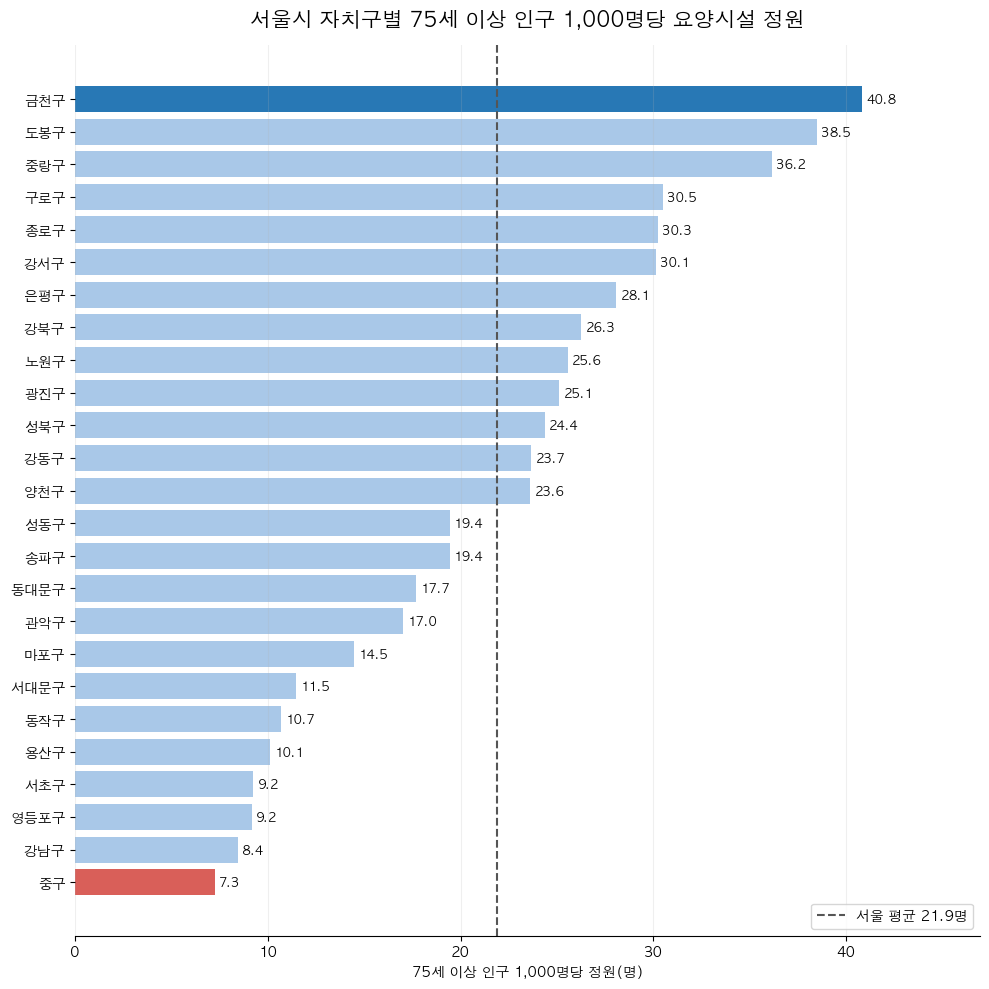

In [22]:
plot_data = analysis.sort_values("75세이상_천명당_정원", ascending=True)
colors = [
    "#D95F59" if gu == lowest["자치구"] else "#2878B5" if gu == highest["자치구"] else "#A9C8E8"
    for gu in plot_data["자치구"]
]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(plot_data["자치구"], plot_data["75세이상_천명당_정원"], color=colors)
ax.axvline(seoul_rate, color="#555555", linestyle="--", linewidth=1.5, label=f"서울 평균 {seoul_rate:.1f}명")
ax.bar_label(bars, labels=[f"{v:.1f}" for v in plot_data["75세이상_천명당_정원"]], padding=3, fontsize=9)
ax.set_title("서울시 자치구별 75세 이상 인구 1,000명당 요양시설 정원", fontsize=15, pad=14)
ax.set_xlabel("75세 이상 인구 1,000명당 정원(명)")
ax.set_ylabel("")
ax.set_xlim(0, plot_data["75세이상_천명당_정원"].max() * 1.15)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5. 해석

- 금천구는 75세 이상 인구 18,095명에 정원 739명으로 1,000명당 40.8명이다.
- 중구는 75세 이상 인구 11,441명에 정원 83명으로 1,000명당 7.3명이다.
- 서울 전체 평균은 1,000명당 약 21.9명이다. 금천구는 평균의 약 1.9배, 중구는 평균의 약 0.3배다.
- 정원 총량만 보면 강서구가 가장 많지만, 75세 이상 인구 규모로 표준화하면 금천구가 가장 높다. 자치구 간 공급을 비교할 때 단순 정원보다 인구 대비 지표가 적합하다.

### 해석상 주의

이 지표는 시설이 소재한 자치구의 공급 밀도를 나타낸다. 실제 입소자는 다른 자치구 시설을 이용할 수 있으므로, 이 수치만으로 접근성이나 미충족 수요를 단정할 수는 없다. 수요 격차를 판단하려면 대기자, 장기요양 인정자, 주소지별 실제 이용자 자료를 함께 봐야 한다.


In [23]:
# 핵심 수치 재현 및 검증
summary = pd.DataFrame({
    "항목": ["최고", "최저", "서울 전체"],
    "자치구": [highest["자치구"], lowest["자치구"], "서울특별시"],
    "75세 이상 인구": [highest["75세이상_인구"], lowest["75세이상_인구"], analysis["75세이상_인구"].sum()],
    "요양시설 정원": [highest["요양시설_정원"], lowest["요양시설_정원"], analysis["요양시설_정원"].sum()],
    "1,000명당 정원": [highest["75세이상_천명당_정원"], lowest["75세이상_천명당_정원"], seoul_rate],
})

assert highest["자치구"] == "금천구"
assert lowest["자치구"] == "중구"
assert round(gap, 1) == 5.6
display(summary.style.format({"75세 이상 인구": "{:,.0f}", "요양시설 정원": "{:,.0f}", "1,000명당 정원": "{:.1f}"}).hide(axis="index"))
print(headline)


항목,자치구,75세 이상 인구,요양시설 정원,"1,000명당 정원"
최고,금천구,"18,095",739,40.8
최저,중구,"11,441",83,7.3
서울 전체,서울특별시,"729,748","15,987",21.9


실제로 75세 이상 인구 1,000명당 요양시설 정원은 금천구가 40.8명인 반면 중구는 7.3명으로 약 5.6배 차이가 난다.


### 출처

- 국민건강보험공단_노인장기요양보험 등급판정 현황: https://www.data.go.kr/data/3051421/fileData.do
- 국민건강보험공단_장기요양기관 시설별 현황: https://www.data.go.kr/data/15124763/fileData.do
